# Jigsaw Puzzle Image Reconstruction

We are given 9 scrambled patches of size 28x28x3 and have to rebuild the original 96x96 RGB image. The patches come from a 3x3 partition of the source image (cells of 32x32), but their arrangement is unknown and each patch has had a 2-pixel border removed by erosion, so the seams between cells are missing. The model has to work out where each patch belongs and fill in the missing border pixels.

## Approach

I treat this as a short pipeline of neural networks:

1. A shared CNN encodes each of the 9 patches into a feature vector, and a small self-attention block lets the patches compare themselves against one another.

2. An attention layer matches the 9 grid positions to the 9 patches, producing a soft assignment. This assignment is supervised during training with the known permutation, which makes the matching accurate.

3. The assignment is used to put the actual patch pixels back into their predicted cells, leaving the eroded seams empty. A U-Net then refines this canvas and inpaints the missing seam pixels.

Because the real patch pixels are carried all the way to the output, most of the image is reconstructed exactly and only the thin seams have to be predicted. Training uses Mean Absolute Error (MAE) on the final image, which is the evaluation metric, together with a cross-entropy term on the assignment.

In [1]:
import os
import numpy as np
import keras
from keras import layers
from keras.utils import PyDataset
import tensorflow as tf
import matplotlib.pyplot as plt

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.20.0
Keras: 3.13.2
GPU available: True


## Dataset

The data comes from STL-10, a collection of 100,000 unlabeled colour images at 96x96 resolution spanning 10 object categories. I only use the unlabeled split, since the task needs no class labels at all.

The download is fairly slow, so Keras caches a local copy after the first run.

In [2]:
def download_and_load_stl10():
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )

    base_dir = os.path.dirname(path)
    data_dir = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, 'rb') as f:
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))
        images = np.transpose(images, (0, 3, 2, 1))

    return images


class PatchGenerator(PyDataset):
    # Produces training examples for the reconstructor.
    # For each image it cuts a 3x3 grid of 32x32 cells, center-crops every
    # cell to 28x28 (the erosion), shuffles the 9 patches, and returns:
    #   X          : the shuffled patches            (B, 9, 28, 28, 3)
    #   'image'    : the original full image         (B, 96, 96, 3)
    #   'assignment': the grid position of each slot (B, 9)  int labels
    # The assignment target lets us supervise the patch-to-position matching.
    #
    # Images are kept as uint8 and divided by 255 one batch at a time. A full
    # float32 copy would be about 8.8 GB for the 80k train images and crashes
    # the Colab runtime, so we avoid it.

    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28,
                 shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images                 # left as uint8 on purpose
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype='float32')
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype='float32')
        pos = np.zeros((actual_batch_size, 9), dtype='int32')

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx].astype('float32') / 255.0   # normalise this image only
            Y[i] = full_img
            patches = []

            for r in range(3):
                for c in range(3):
                    y_start = r * self.patch_size
                    x_start = c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            order = np.random.permutation(9)
            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]
                pos[i, slot_idx] = original_pos   # true grid position of this slot

        return X, {'image': Y, 'assignment': pos}

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [3]:
images = download_and_load_stl10()
print(f"Loaded {images.shape[0]} images, shape: {images.shape}")

2640397119/2640397119 ━━━━━━━━━━━━━━━━━━━━ 62s 0us/step
Loading data from: /root/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Loaded 100000 images, shape: (100000, 96, 96, 3)


In [4]:
train_images = images[:80000]
val_images   = images[80000:90000]
test_images  = images[90000:]

print(f"Train: {len(train_images)}  Val: {len(val_images)}  Test: {len(test_images)}")

Train: 80000  Val: 10000  Test: 10000


In [5]:
BATCH_SIZE = 32

train_generator = PatchGenerator(train_images, batch_size=BATCH_SIZE, shuffle=True)
val_generator   = PatchGenerator(val_images,   batch_size=BATCH_SIZE, shuffle=False)
test_generator  = PatchGenerator(test_images,  batch_size=BATCH_SIZE, shuffle=False)

## Data Visualisation

As a quick check, the cell below takes one test sample and shows the original 96x96 image next to its puzzle version, i.e. the scrambled patches placed on a blank canvas.

In [6]:
def plot_puzzle(patches, ordering=None):
    # Draw the 9 patches on a 96x96 canvas at the positions given by ordering.
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    canvas = np.ones((96, 96, 3), dtype=np.float32)
    cell_dim, patch_dim = 32, 28
    margin = (cell_dim - patch_dim) // 2

    for i in range(9):
        grid_pos = order[i]
        row, col = grid_pos // 3, grid_pos % 3
        y_start = row * cell_dim + margin
        x_start = col * cell_dim + margin
        canvas[y_start : y_start + patch_dim, x_start : x_start + patch_dim] = patches[i]

    plt.figure(figsize=(4, 4))
    plt.imshow(canvas)
    plt.axis('off')
    plt.title('Scrambled patches')
    plt.show()

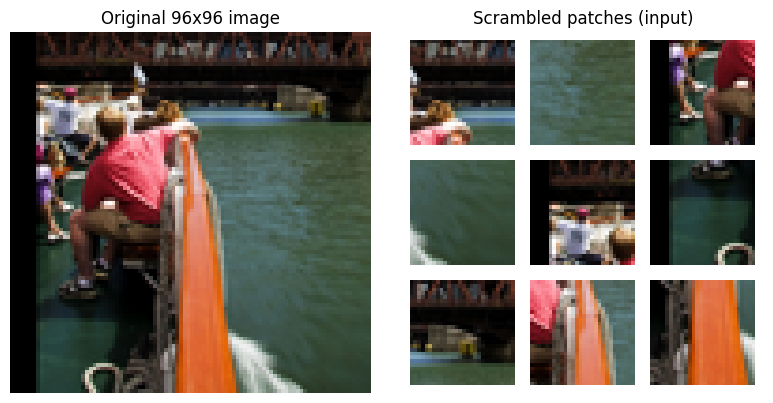

In [7]:
sample_patches, sample_targets = test_generator[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_targets['image'][0])
axes[0].set_title('Original 96x96 image')
axes[0].axis('off')

canvas = np.ones((96, 96, 3), dtype=np.float32)
cell_dim, patch_dim, margin = 32, 28, 2
for k in range(9):
    r, c = k // 3, k % 3
    canvas[r*cell_dim+margin : r*cell_dim+margin+patch_dim,
           c*cell_dim+margin : c*cell_dim+margin+patch_dim] = sample_patches[0, k]
axes[1].imshow(canvas)
axes[1].set_title('Scrambled patches (input)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Indicative Baseline

As a reference point, the baseline takes the pixel-wise mean of the 9 patches and tiles it to fill the 96x96 canvas. This trivial predictor reaches an **MAE of about 0.1826**, which is the floor the trained model has to beat.

In [8]:
def mean_patch_image(patches):
    # Baseline: average the 9 patches and tile that mean patch over the canvas.
    B = tf.shape(patches)[0]
    mean_patch = tf.reduce_mean(patches, axis=1)          # (B, 28, 28, 3)
    mean_patches = tf.repeat(mean_patch[:, None], 9, axis=1)
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out


baseline_vals = []
for i in range(len(test_generator)):
    bx, bt = test_generator[i]
    by = bt['image']
    pred = np.array(mean_patch_image(bx))
    baseline_vals.append(float(np.mean(np.abs(pred - by))))

print(f"Baseline MAE : {np.mean(baseline_vals):.6f}")
print(f"Baseline std : {np.std(baseline_vals):.6f}")

Baseline MAE : 0.182387
Baseline std : 0.010261


## Model Architecture

### Design rationale

The 9 patches arrive in arbitrary order, so the matching part of the model is permutation-equivariant: no position information is attached to the input slots. The network has four parts.

#### 1. Shared patch encoder
A small CNN with shared weights (applied through `TimeDistributed`) turns each 28x28x3 patch into a 128-dimensional vector.

#### 2. Self-attention over patches
Two light transformer-style blocks let the 9 patch embeddings attend to one another, so each patch is represented in the context of the others. This helps disambiguate patches that look similar on their own.

#### 3. Position-to-patch assignment
Nine learnable position queries (one per grid cell) score every patch through scaled dot-product attention, giving a 9x9 score matrix. A softmax over patches gives, for each position, a soft selection of the patch that belongs there; a softmax over positions gives a per-patch distribution that is supervised with the true permutation.

#### 4. Assembly and U-Net inpainting
The soft assignment places the real patch pixels into their predicted 28x28 cell centres on a 96x96 canvas, with the eroded 2-pixel seams left blank and flagged by a binary mask. A U-Net (three down/up stages with skip connections) takes the canvas and mask and outputs the final image, copying the known pixels and filling the seams. A sigmoid keeps outputs in [0, 1].

Only the patches are needed at test time: a second model that shares the same weights maps the 9 patches straight to the reconstructed image, and that is the one we evaluate and save.

### Parameter budget
The model stays well under the 6 million trainable parameters allowed; the exact count is printed by the cell below.

In [9]:
@keras.saving.register_keras_serializable(package='jigsaw')
class PositionQueries(layers.Layer):
    # One learnable query vector per grid position, tiled across the batch.
    def __init__(self, num_positions, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_positions = num_positions
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.q = self.add_weight(
            name='q',
            shape=(self.num_positions, self.embed_dim),
            initializer='glorot_uniform',
            trainable=True,
        )

    def call(self, x):
        b = tf.shape(x)[0]
        return tf.tile(self.q[None], [b, 1, 1])

    def get_config(self):
        c = super().get_config()
        c.update(num_positions=self.num_positions, embed_dim=self.embed_dim)
        return c


@keras.saving.register_keras_serializable(package='jigsaw')
class DotScores(layers.Layer):
    # scores[b, p, s] = (position query p) . (patch key s) / sqrt(d)
    def call(self, inputs):
        q, k = inputs
        d = tf.cast(tf.shape(q)[-1], tf.float32)
        return tf.einsum('bpd,bsd->bps', q, k) / tf.sqrt(d)

    def compute_output_shape(self, input_shape):
        q_shape, k_shape = input_shape
        return (q_shape[0], q_shape[1], k_shape[1])


@keras.saving.register_keras_serializable(package='jigsaw')
class Assemble(layers.Layer):
    # Place the real patch pixels into their predicted cells.
    # inputs: M (b, 9, 9) soft weights over patches for each position,
    #         patches (b, 9, 28, 28, 3) the actual patch pixels.
    # output: (b, 96, 96, 4) = assembled RGB canvas + a known-pixel mask.
    def call(self, inputs):
        M, patches = inputs
        placed = tf.einsum('bps,bshwc->bphwc', M, patches)      # (b, 9, 28, 28, 3)
        b = tf.shape(placed)[0]
        placed = tf.pad(placed, [[0, 0], [0, 0], [2, 2], [2, 2], [0, 0]])  # 28 -> 32
        placed = tf.reshape(placed, (b, 3, 3, 32, 32, 3))
        placed = tf.transpose(placed, [0, 1, 3, 2, 4, 5])
        canvas = tf.reshape(placed, (b, 96, 96, 3))

        ones = tf.ones((1, 9, 28, 28, 1), dtype=canvas.dtype)
        m = tf.pad(ones, [[0, 0], [0, 0], [2, 2], [2, 2], [0, 0]])
        m = tf.reshape(m, (1, 3, 3, 32, 32, 1))
        m = tf.transpose(m, [0, 1, 3, 2, 4, 5])
        m = tf.reshape(m, (1, 96, 96, 1))
        m = tf.tile(m, [b, 1, 1, 1])
        return tf.concat([canvas, m], axis=-1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0][0], 96, 96, 4)


def build_patch_encoder(embed_dim=128):
    # Shared CNN that maps one 28x28x3 patch to an embed_dim vector.
    patch_in = keras.Input(shape=(28, 28, 3))

    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(patch_in)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, 3, padding='same', strides=2, use_bias=False)(x)   # 14x14
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(128, 3, padding='same', strides=2, use_bias=False)(x)  # 7x7
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(embed_dim, activation='relu')(x)
    return keras.Model(patch_in, x, name='patch_encoder')


def build_unet(inp):
    # Encoder/decoder with skip connections. Copies known pixels and
    # inpaints the eroded seams. Input is (96, 96, 4), output (96, 96, 3).
    def cbr(t, f):
        t = layers.Conv2D(f, 3, padding='same', use_bias=False)(t)
        t = layers.BatchNormalization()(t)
        t = layers.Activation('relu')(t)
        return t

    c1 = cbr(inp, 32); c1 = cbr(c1, 32)
    p1 = layers.MaxPooling2D()(c1)            # 48
    c2 = cbr(p1, 64); c2 = cbr(c2, 64)
    p2 = layers.MaxPooling2D()(c2)            # 24
    c3 = cbr(p2, 128); c3 = cbr(c3, 128)
    p3 = layers.MaxPooling2D()(c3)            # 12

    b = cbr(p3, 128); b = cbr(b, 128)

    u3 = layers.UpSampling2D()(b)             # 24
    u3 = layers.Concatenate()([u3, c3]); u3 = cbr(u3, 128); u3 = cbr(u3, 64)
    u2 = layers.UpSampling2D()(u3)            # 48
    u2 = layers.Concatenate()([u2, c2]); u2 = cbr(u2, 64); u2 = cbr(u2, 32)
    u1 = layers.UpSampling2D()(u2)            # 96
    u1 = layers.Concatenate()([u1, c1]); u1 = cbr(u1, 32); u1 = cbr(u1, 32)

    return layers.Conv2D(3, 3, padding='same', activation='sigmoid', name='image')(u1)


def build_models(embed_dim=128, num_heads=4):
    # Returns (train_model, infer_model). They share all weights.
    # train_model has two outputs (image + assignment) for training;
    # infer_model maps the 9 patches straight to the reconstructed image.
    patches_in = keras.Input(shape=(9, 28, 28, 3), name='patches')

    encoder = build_patch_encoder(embed_dim)
    emb = layers.TimeDistributed(encoder, name='td_encoder')(patches_in)   # (b, 9, D)

    # Self-attention so patches are represented in the context of the others.
    x = emb
    for i in range(2):
        a = layers.MultiHeadAttention(num_heads=num_heads,
                                      key_dim=embed_dim // num_heads,
                                      name=f'self_attn_{i}')(x, x)
        x = layers.LayerNormalization()(layers.Add()([x, a]))
        f = layers.Dense(embed_dim * 2, activation='relu')(x)
        f = layers.Dense(embed_dim)(f)
        x = layers.LayerNormalization()(layers.Add()([x, f]))
    patch_ctx = x

    # Position-to-patch assignment via scaled dot-product attention.
    posq = PositionQueries(9, embed_dim, name='pos_queries')(patch_ctx)
    q = layers.Dense(embed_dim, name='q_proj')(posq)
    k = layers.Dense(embed_dim, name='k_proj')(patch_ctx)
    scores = DotScores(name='scores')([q, k])                  # (b, 9pos, 9slot)

    M = layers.Softmax(axis=-1, name='slot_weights')(scores)   # per position, over patches
    scores_t = layers.Permute((2, 1))(scores)                  # (b, 9slot, 9pos)
    assignment = layers.Softmax(axis=-1, name='assignment')(scores_t)

    # Place the real pixels, then inpaint.
    canvas = Assemble(name='assemble')([M, patches_in])        # (b, 96, 96, 4)
    image = build_unet(canvas)                                 # (b, 96, 96, 3)

    train_model = keras.Model(patches_in, [image, assignment], name='jigsaw_train')
    infer_model = keras.Model(patches_in, image, name='jigsaw_reconstructor')
    return train_model, infer_model

In [10]:
train_model, model = build_models(embed_dim=128, num_heads=4)
model.summary()
print(f"\nTotal trainable parameters: {model.count_params():,}")

Model: "jigsaw_reconstructor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches             │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_encoder          │ (None, 9, 128)    │    295,520 │ patches[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attn_0         │ (None, 9, 128)    │     66,048 │ td_encoder[0][0], │
│ (MultiHeadAttentio… │                   │            │ td_encoder[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9, 128)    │          0 │ td_encoder[0][0], │
│                     │                   │            │ self_attn_0[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 9, 128)    │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 9, 256)    │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 9, 128)    │     32,896 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 9, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attn_1         │ (None, 9, 128)    │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 9, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ self_attn_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9, 256)    │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 9, 128)    │     32,896 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 9, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 128)    │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_queries         │ (None, 9, 128)    │      1,152 │ layer_normalizat… │
│ (PositionQueries)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_proj (Dense)      │ (None, 9, 128)    │     16,512 │ pos_queries[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,669,955 (6.37 MB)

 Trainable params: 1,667,011 (6.36 MB)

 Non-trainable params: 2,944 (11.50 KB)


Total trainable parameters: 1,669,955


## Training

The training model has two outputs: the reconstructed image and the patch-to-position assignment. The image is trained with **MAE** (the evaluation metric) and the assignment with cross-entropy against the known permutation, combined as `MAE + 0.3 * cross_entropy`. Adam is used, the learning rate is halved when the validation loss plateaus, and training stops early once it stops improving; the best weights are restored at the end.

Only the patches are needed at inference, so the single-output `model` (which shares these weights) is what we evaluate and save afterwards.

In [11]:
train_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={'image': 'mae', 'assignment': 'sparse_categorical_crossentropy'},
    loss_weights={'image': 1.0, 'assignment': 0.3},
    metrics={'image': 'mae'},
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
    ),
]

history = train_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 311s 105ms/step - assignment_loss: 1.4975 - image_loss: 0.1164 - image_mae: 0.1164 - loss: 0.5657 - val_assignment_loss: 1.2853 - val_image_loss: 0.0987 - val_image_mae: 0.0987 - val_loss: 0.4844 - learning_rate: 0.0010
Epoch 2/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 260s 104ms/step - assignment_loss: 1.2039 - image_loss: 0.0930 - image_mae: 0.0930 - loss: 0.4542 - val_assignment_loss: 1.1291 - val_image_loss: 0.0868 - val_image_mae: 0.0869 - val_loss: 0.4256 - learning_rate: 0.0010
Epoch 3/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 259s 104ms/step - assignment_loss: 1.0830 - image_loss: 0.0835 - image_mae: 0.0835 - loss: 0.4084 - val_assignment_loss: 1.0228 - val_image_loss: 0.0782 - val_image_mae: 0.0782 - val_loss: 0.3851 - learning_rate: 0.0010
Epoch 4/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 256s 103ms/step - assignment_loss: 1.0051 - image_loss: 0.0776 - image_mae: 0.0776 - loss: 0.3791 - val_assignment_loss: 0.9525 - val_image_loss: 0.0762 - val_image_mae: 0.

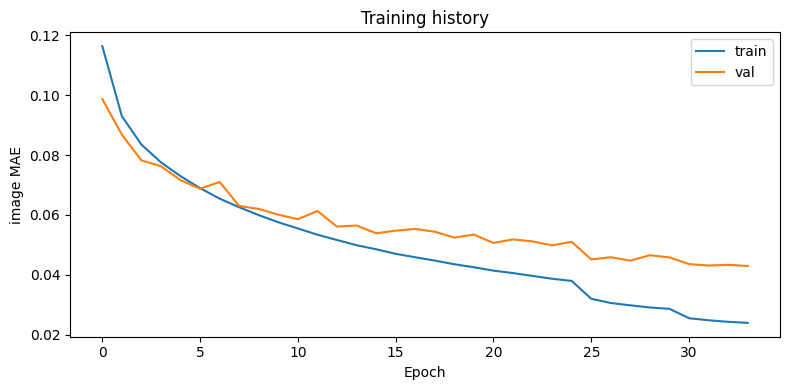

In [12]:
# Plot the image-reconstruction MAE over epochs (fall back to total loss).
key = 'image_mae' if 'image_mae' in history.history else 'loss'
vkey = 'val_' + key

plt.figure(figsize=(8, 4))
plt.plot(history.history[key],  label='train')
plt.plot(history.history[vkey], label='val')
plt.xlabel('Epoch')
plt.ylabel('image MAE')
plt.title('Training history')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation on the Test Set

The model is evaluated over the full test set of 10,000 images. I run through it batch by batch, collect the per-batch MAE values, and report both the mean and the standard deviation.

In [13]:
# Evaluate the inference model (single output) over the full test set.
mae_values = []

for i in range(len(test_generator)):
    x_batch, t_batch = test_generator[i]
    y_batch = t_batch['image']
    y_pred = model.predict(x_batch, verbose=0)
    mae_values.append(float(np.mean(np.abs(y_batch - y_pred))))

mae_mean = np.mean(mae_values)
mae_std  = np.std(mae_values)

print(f"Test MAE  : {mae_mean:.6f}")
print(f"Test std  : {mae_std:.6f}")

Test MAE  : 0.045822
Test std  : 0.007290


## Visual Results

For a few test samples I show three images side by side: the scrambled input patches, the ground-truth image, and the reconstruction produced by the network.

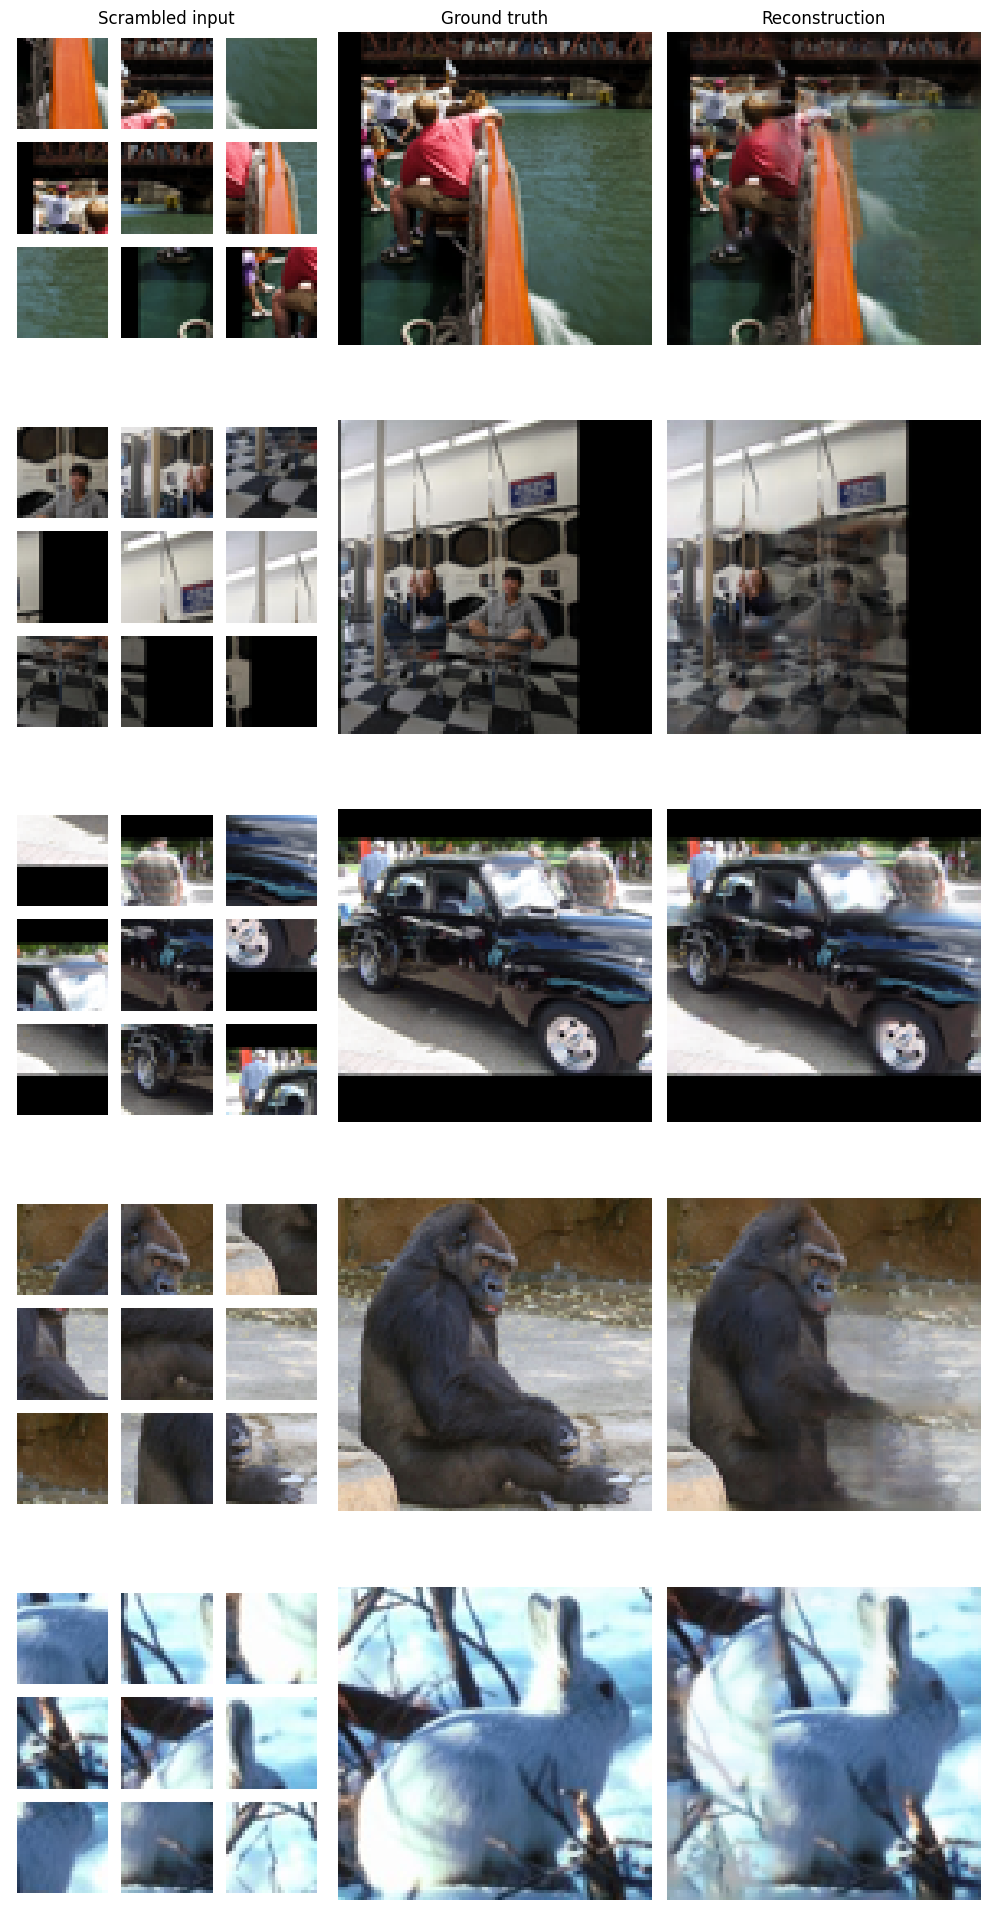

In [14]:
def show_results(patches_batch, targets_batch, preds_batch, n=5):
    cell_dim, patch_dim, margin = 32, 28, 2

    fig, axes = plt.subplots(n, 3, figsize=(10, 4 * n))
    axes[0, 0].set_title('Scrambled input', fontsize=12)
    axes[0, 1].set_title('Ground truth',    fontsize=12)
    axes[0, 2].set_title('Reconstruction',  fontsize=12)

    for row in range(n):
        canvas = np.ones((96, 96, 3), dtype=np.float32)
        for k in range(9):
            r, c = k // 3, k % 3
            canvas[r*cell_dim+margin : r*cell_dim+margin+patch_dim,
                   c*cell_dim+margin : c*cell_dim+margin+patch_dim] = patches_batch[row, k]
        axes[row, 0].imshow(canvas)
        axes[row, 1].imshow(np.clip(targets_batch[row], 0, 1))
        axes[row, 2].imshow(np.clip(preds_batch[row],  0, 1))
        for ax in axes[row]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()


x_vis, t_vis = test_generator[0]
y_vis = t_vis['image']
y_hat = model.predict(x_vis, verbose=0)
show_results(x_vis, y_vis, y_hat, n=5)

## Saving the Model Weights

The trained inference model is saved in the Keras format and uploaded to Google Drive, so it can be shared and downloaded again with `gdown`.

**Steps to make the weights publicly accessible:**
1. Run the cell below to mount Drive and save the weights.
2. In Drive, right-click the file, choose *Share*, and set access to *Anyone with the link* as *Viewer*.
3. Copy the file ID from the share URL and use it in the verification cell.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/jigsaw_best_weights.keras'
model.save(save_path)
print(f"Model saved to {save_path}")

Mounted at /content/drive
Model saved to /content/drive/MyDrive/jigsaw_best_weights.keras


In [20]:
FILE_ID_OR_URL = '1DF5MPP-FLoRWHCYApIchrrJvHcf0kLVY'

import subprocess
subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
import gdown

gdown.download(id=FILE_ID_OR_URL, output='downloaded_weights.keras',
               quiet=False, fuzzy=True)

loaded_model = keras.models.load_model(
    'downloaded_weights.keras',
    custom_objects={
        'PositionQueries': PositionQueries,
        'DotScores': DotScores,
        'Assemble': Assemble,
    }
)

# Quick sanity check on a few test samples.
x_check, t_check = test_generator[0]
y_check = t_check['image']
pred_check = loaded_model.predict(x_check[:4], verbose=0)
mae_check = float(np.mean(np.abs(y_check[:4] - pred_check)))
print(f"MAE on 4 samples (loaded model): {mae_check:.6f}")
print("Weight loading verified successfully.")

Downloading...
From: https://drive.google.com/uc?id=1DF5MPP-FLoRWHCYApIchrrJvHcf0kLVY
To: /content/downloaded_weights.keras
100%|██████████| 7.03M/7.03M [00:00<00:00, 44.0MB/s]


MAE on 4 samples (loaded model): 0.039202
Weight loading verified successfully.


## Summary

| | Value |
|---|---|
| Trainable parameters | 1,669,955 (under 6 M) |
| Image loss | MAE |
| Assignment loss | sparse categorical cross-entropy (weight 0.3) |
| Optimiser | Adam |
| Baseline MAE | 0.1826 |
| **Model test MAE** | **0.0458** |
| **Model test std** | **0.0073** |

### Architecture components

- **Patch encoder** - shared CNN mapping each 28x28x3 patch to a 128-dim vector.
- **Self-attention** - two transformer-style blocks over the 9 patch embeddings.
- **Assignment** - learnable position queries score the patches (9x9), giving a soft patch-to-position matching that is supervised by the true permutation.
- **Assembly** - the assignment places the real patch pixels into their cells on a 96x96 canvas, with the eroded seams left blank and marked by a mask.
- **U-Net** - encoder/decoder with skip connections that copies the known pixels and inpaints the seams, ending in Conv2D(3, sigmoid).

### Results

The model reaches a test MAE of **0.0458** (std 0.0073), against the baseline of 0.1826: roughly a 4x reduction in error.

### Constraints satisfied

- The whole pipeline is neural (encoder, attention, assignment, U-Net); no classical search or matching algorithm is used.
- No pretrained models.
- Under 6 million trainable parameters.
- Implemented in Keras and runs on Google Colab.
- Single notebook submission.